# Kaggle Predict F1 Pit Stops: LightGBM Tuning

This notebook tunes the strongest baseline model from `02_baseline_modeling.ipynb`: LightGBM.

Goals:

- Reuse the same feature engineering as the EDA and baseline notebooks.
- Run a compact, reproducible hyperparameter search.
- Compare tuned LightGBM against the baseline LightGBM score.
- Train the best configuration and create `submission.csv`.

## 1. Setup

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Use FAST mode for quick iteration, then set False for the final tuning run.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5
N_ITER = 12 if RUN_FAST else 30

## 2. Load Data

In [2]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"DATA_DIR: {DATA_DIR}")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train[TARGET].mean():.5f}")

DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train: (439140, 16)
test: (188165, 15)
target positive rate: 0.19898


## 3. Feature Engineering

In [3]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    if {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]

    if {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)

    if {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)

    if {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(["WET", "INTERMEDIATE"]).astype("int8")

    return reduce_memory_usage(out)


train_fe = add_features(train)
test_fe = add_features(test)

if RUN_FAST and len(train_fe) > FAST_SAMPLE_SIZE:
    train_fe = (
        train_fe.groupby(TARGET, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, FAST_SAMPLE_SIZE / len(train)), random_state=RANDOM_STATE))
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    print(f"RUN_FAST sample shape: {train_fe.shape}")

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype("int8")
X_test = test_fe.copy()

print("Features:", X.shape[1])
print("Positive rate:", y.mean())

RUN_FAST sample shape: (180000, 29)
Features: 28
Positive rate: 0.19898333333333335


## 4. Preprocessing and Scoring

In [4]:
def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    features = df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def evaluate_predictions(y_true, y_pred) -> dict:
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


preprocessor = make_preprocessor(X)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 5. Hyperparameter Search

In [5]:
base_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

param_grid = {
    "learning_rate": [0.015, 0.02, 0.03, 0.04, 0.05],
    "num_leaves": [31, 47, 63, 95, 127],
    "min_child_samples": [20, 40, 60, 100, 150],
    "subsample": [0.75, 0.85, 0.95, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.03, 0.1, 0.3, 1.0],
    "reg_lambda": [0.3, 1.0, 2.0, 5.0, 10.0],
    "max_bin": [127, 255, 511],
}

candidate_params = list(ParameterSampler(param_grid, n_iter=N_ITER, random_state=RANDOM_STATE))
print(f"Testing {len(candidate_params)} LightGBM configurations")

Testing 12 LightGBM configurations


In [6]:
def cross_validate_lgbm(params: dict, candidate_id: int) -> dict:
    start = time.time()
    oof = np.zeros(len(X), dtype=np.float32)
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        fold_preprocessor = make_preprocessor(X_train_raw)
        X_train = fold_preprocessor.fit_transform(X_train_raw)
        X_valid = fold_preprocessor.transform(X_valid_raw)

        model = LGBMClassifier(**base_params, **params)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = pred

        scores = evaluate_predictions(y_valid, pred)
        scores.update({"candidate": candidate_id, "fold": fold})
        fold_rows.append(scores)

        del fold_preprocessor, X_train, X_valid, model
        gc.collect()

    overall = evaluate_predictions(y, oof)
    overall.update({"candidate": candidate_id, "fold": "oof", "fit_seconds": time.time() - start})
    overall.update(params)
    return overall, fold_rows, oof


search_rows = []
fold_rows_all = []
best_oof = None
best_score = -np.inf

for candidate_id, params in enumerate(candidate_params, start=1):
    print(f"\nCandidate {candidate_id}/{len(candidate_params)}: {params}")
    result, fold_rows, oof = cross_validate_lgbm(params, candidate_id)
    search_rows.append(result)
    fold_rows_all.extend(fold_rows)

    if result["roc_auc"] > best_score:
        best_score = result["roc_auc"]
        best_oof = oof.copy()

    print(
        f"OOF auc={result['roc_auc']:.5f}, "
        f"ap={result['average_precision']:.5f}, "
        f"logloss={result['log_loss']:.5f}, "
        f"seconds={result['fit_seconds']:.1f}"
    )

search_results = pd.DataFrame(search_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
fold_results = pd.DataFrame(fold_rows_all)
search_results.head(10)


Candidate 1/12: {'subsample': 0.95, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'num_leaves': 127, 'min_child_samples': 100, 'max_bin': 127, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
OOF auc=0.94684, ap=0.80299, logloss=0.23022, seconds=76.7

Candidate 2/12: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.3, 'num_leaves': 95, 'min_child_samples': 100, 'max_bin': 255, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
OOF auc=0.94597, ap=0.79892, logloss=0.23265, seconds=64.5

Candidate 3/12: {'subsample': 0.75, 'reg_lambda': 5.0, 'reg_alpha': 0.03, 'num_leaves': 127, 'min_child_samples': 100, 'max_bin': 255, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
OOF auc=0.94677, ap=0.80249, logloss=0.23043, seconds=79.6

Candidate 4/12: {'subsample': 0.95, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'num_leaves': 47, 'min_child_samples': 60, 'max_bin': 511, 'learning_rate': 0.04, 'colsample_bytree': 0.9}
OOF auc=0.94670, ap=0.80200, logloss=0.23054, seconds=58.4

Candidate 5/12: {'subsample': 1.0

,roc_auc,average_precision,log_loss,candidate,fold,fit_seconds,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_bin,learning_rate,colsample_bytree
0,0.947282,0.804845,0.229346,9,oof,86.937192,0.95,10.0,1.00,127,150,255,0.020,0.9
1,0.947248,0.804297,0.229308,7,oof,62.149356,0.95,1.0,1.00,95,150,127,0.030,0.8
2,0.946837,0.802986,0.230223,1,oof,76.668437,0.95,10.0,0.10,127,100,127,0.020,1.0
3,0.946818,0.802110,0.230353,8,oof,63.153214,0.85,10.0,0.03,95,150,127,0.040,1.0
4,0.946775,0.802490,0.230429,3,oof,79.631321,0.75,5.0,0.03,127,100,255,0.030,1.0
5,0.946697,0.801996,0.230545,4,oof,58.372898,0.95,5.0,1.00,47,60,511,0.040,0.9
6,0.946450,0.800509,0.230997,6,oof,60.680698,0.75,2.0,0.30,63,20,511,0.050,0.9
7,0.946295,0.800464,0.231357,11,oof,84.313563,0.75,1.0,0.03,95,60,511,0.020,1.0
8,0.946254,0.801455,0.231550,5,oof,93.659175,1.00,10.0,0.30,95,150,511,0.015,1.0
9,0.945968,0.798919,0.232650,2,oof,64.476695,1.00,1.0,0.30,95,100,255,0.050,1.0


## 6. Review Tuning Results

,candidate,roc_auc,average_precision,log_loss,fit_seconds,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_bin,learning_rate,colsample_bytree
0,9,0.947282,0.804845,0.229346,86.937192,0.95,10.0,1.00,127,150,255,0.020,0.9
1,7,0.947248,0.804297,0.229308,62.149356,0.95,1.0,1.00,95,150,127,0.030,0.8
2,1,0.946837,0.802986,0.230223,76.668437,0.95,10.0,0.10,127,100,127,0.020,1.0
3,8,0.946818,0.802110,0.230353,63.153214,0.85,10.0,0.03,95,150,127,0.040,1.0
4,3,0.946775,0.802490,0.230429,79.631321,0.75,5.0,0.03,127,100,255,0.030,1.0
5,4,0.946697,0.801996,0.230545,58.372898,0.95,5.0,1.00,47,60,511,0.040,0.9
6,6,0.946450,0.800509,0.230997,60.680698,0.75,2.0,0.30,63,20,511,0.050,0.9
7,11,0.946295,0.800464,0.231357,84.313563,0.75,1.0,0.03,95,60,511,0.020,1.0
8,5,0.946254,0.801455,0.231550,93.659175,1.00,10.0,0.30,95,150,511,0.015,1.0
9,2,0.945968,0.798919,0.232650,64.476695,1.00,1.0,0.30,95,100,255,0.050,1.0


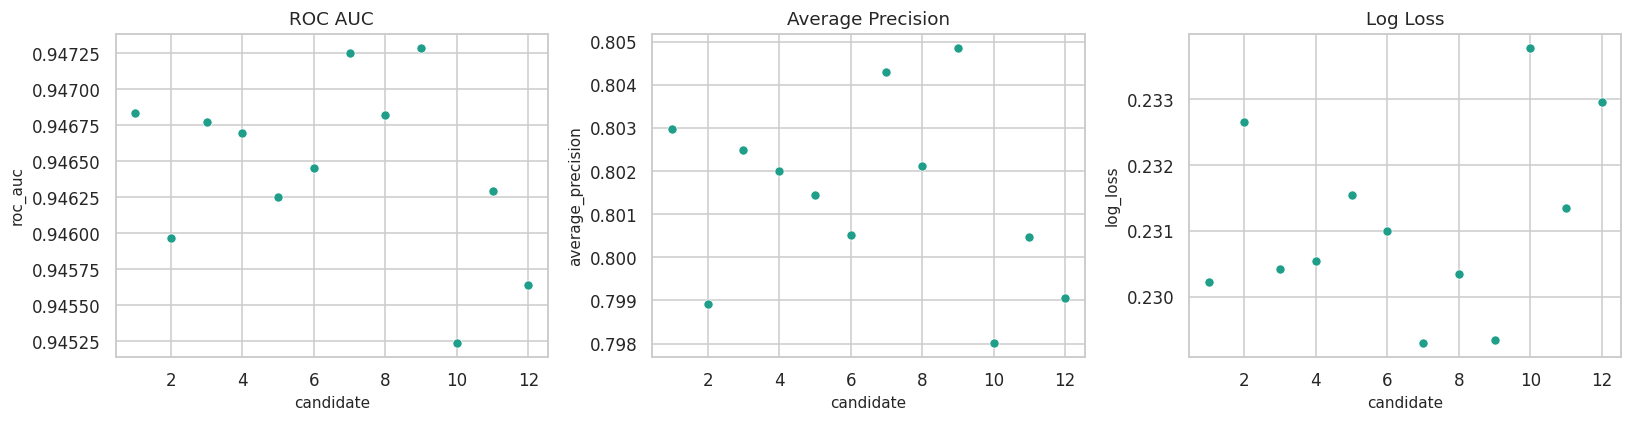

In [7]:
metric_cols = ["roc_auc", "average_precision", "log_loss", "fit_seconds"]
param_cols = [c for c in search_results.columns if c not in metric_cols + ["candidate", "fold"]]
display(search_results[["candidate"] + metric_cols + param_cols].head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, ["roc_auc", "average_precision", "log_loss"], ["ROC AUC", "Average Precision", "Log Loss"]):
    sns.scatterplot(data=search_results, x="candidate", y=metric, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Train Best Model and Submit

In [8]:
best_row = search_results.iloc[0]
best_params = {col: best_row[col] for col in param_grid.keys()}
print("Best candidate:", int(best_row["candidate"]))
print("Best OOF ROC AUC:", round(best_row["roc_auc"], 6))
print("Best params:", best_params)

final_preprocessor = make_preprocessor(X)
X_train_all = final_preprocessor.fit_transform(X)
X_test_all = final_preprocessor.transform(X_test)

final_model = LGBMClassifier(**base_params, **best_params)
final_model.fit(X_train_all, y)

test_pred = final_model.predict_proba(X_test_all)[:, 1]
test_pred = np.clip(test_pred, 1e-6, 1 - 1e-6)

submission = sample_submission.copy()
submission[TARGET] = test_pred
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

search_results.to_csv(OUTPUT_DIR / "lightgbm_tuning_results.csv", index=False)
fold_results.to_csv(OUTPUT_DIR / "lightgbm_tuning_fold_results.csv", index=False)

print("Saved:", submission_path)
submission.head()

Best candidate: 9
Best OOF ROC AUC: 0.947282
Best params: {'learning_rate': np.float64(0.02), 'num_leaves': np.int64(127), 'min_child_samples': np.int64(150), 'subsample': np.float64(0.95), 'colsample_bytree': np.float64(0.9), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(10.0), 'max_bin': np.int64(255)}
Saved: /kaggle/working/submission.csv


,id,PitNextLap
0,439140,0.004559
1,439141,0.002991
2,439142,0.001851
3,439143,0.154017
4,439144,0.849321


## 8. Follow-Up Ideas

- Re-run with `RUN_FAST = False` before trusting the final ranking.
- If tuned LightGBM improves only marginally, spend more time on feature sets and validation diagnostics.
- Compare with an XGBoost tuning notebook only if full-data LightGBM does not clearly separate.
- Add calibration analysis if the competition metric rewards probability quality directly.